# cNMF and GEP analysis for sample CCG1106_084_T1 with MYC clustered SV event

In [1]:
from cnmf import cNMF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import os
import palettable
import gseapy as gp
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy import stats
import seaborn as sns

In [2]:
output_dir = "../outputs/cnmf_output_CCG1106_084_T1"
name = "CCG1106_084_T1_cNMF"
os.makedirs(output_dir, exist_ok=True)
cnmf_obj = cNMF(
    output_dir=output_dir,
    name=name
)

In [3]:
# 1. Load and preprocess for HVG selection
adata = sc.read_h5ad('../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_084_T1.h5ad')
adata.layers['counts'] = adata.X.copy() # Store raw counts 

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Write HVG subset with raw counts for cNMF
adata_cnmf = adata[:, adata.var['highly_variable']].copy()
adata_cnmf.X = adata_cnmf.layers['counts']  # restore raw counts
adata_cnmf.write_h5ad('../data/for_cnmf.h5ad')

[Worker 0]. Starting task 0.
[Worker 0]. Starting task 1.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 3.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 5.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 7.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 9.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 11.
[Worker 0]. Starting task 12.
[Worker 0]. Starting task 13.
[Worker 0]. Starting task 14.
[Worker 0]. Starting task 15.
[Worker 0]. Starting task 16.
[Worker 0]. Starting task 17.
[Worker 0]. Starting task 18.
[Worker 0]. Starting task 19.
[Worker 0]. Starting task 20.
[Worker 0]. Starting task 21.
[Worker 0]. Starting task 22.
[Worker 0]. Starting task 23.
[Worker 0]. Starting task 24.
[Worker 0]. Starting task 25.
[Worker 0]. Starting task 26.
[Worker 0]. Starting task 27.
[Worker 0]. Starting task 28.
[Worker 0]. Starting task 29.
[Worker 0]. Starting task 30.
[Worker 0]. Starting task 31.
[Worker 0]. Starting task 32.
[Worker 0]. Starting

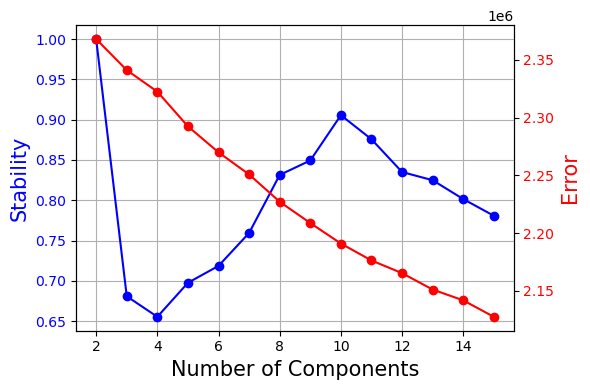

In [ ]:
cnmf_obj.prepare(
    counts_fn="../data/for_cnmf.h5ad",
    components=np.arange(2, 16), # test k from 2 to 15
    n_iter=100,
    seed=14
)

cnmf_obj.factorize(worker_i=0, total_workers=1) # Factorize

cnmf_obj.combine() # Combine results

cnmf_obj.k_selection_plot() # K selection plot


Running consensus for K=10...


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


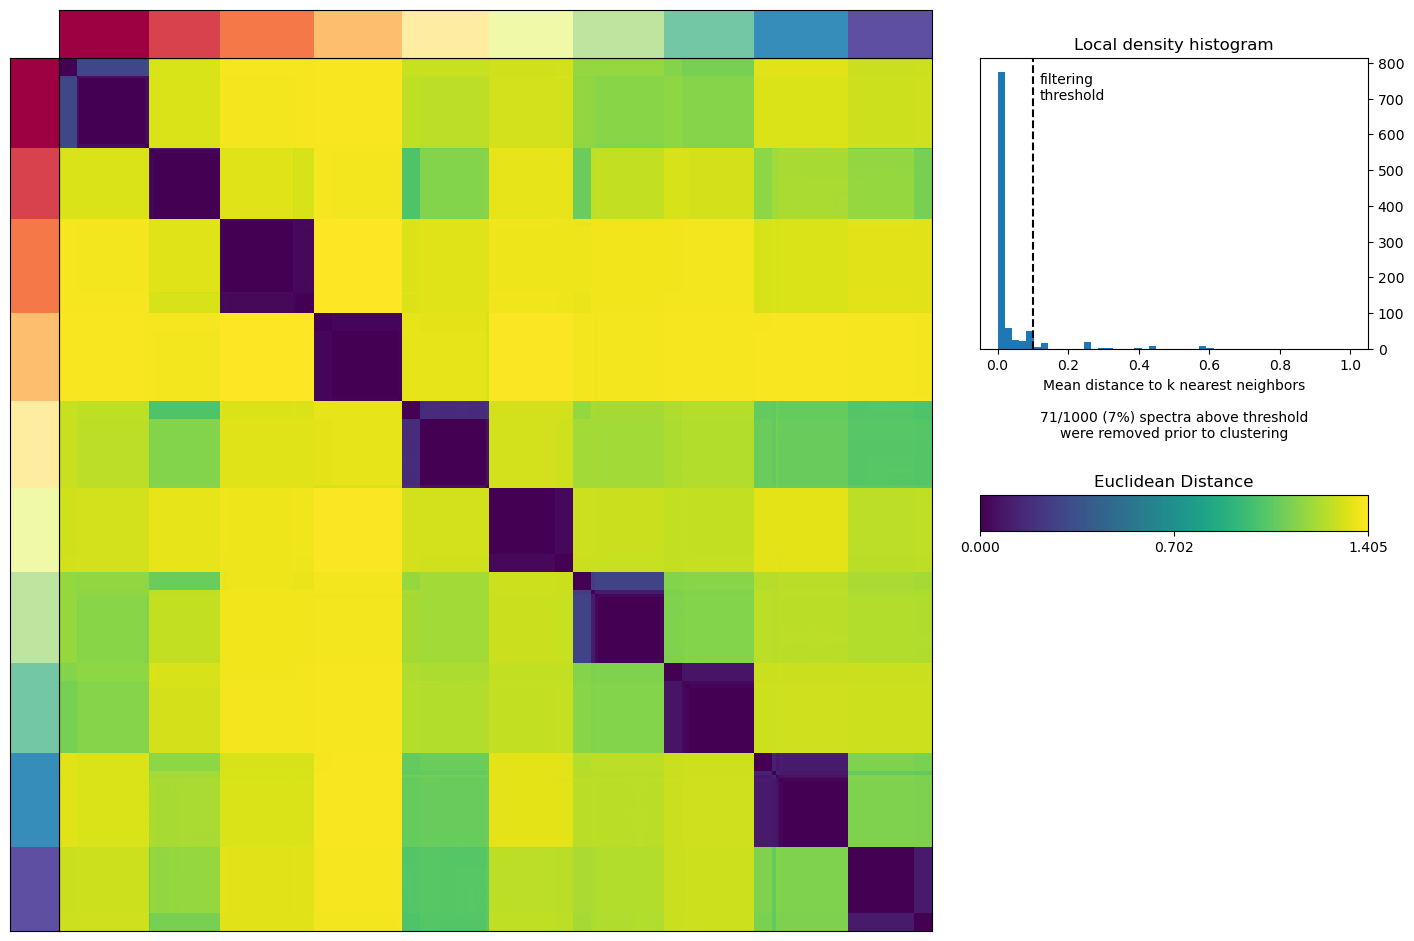

In [ ]:
k_values = [10]

for k in k_values:
    print(f"\nRunning consensus for K={k}...")
    cnmf_obj.consensus(
        k=k,
        density_threshold=0.1
    )

In [4]:
adata = sc.read_h5ad('../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_084_T1.h5ad')
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

selected_K = 10

# load cNMF results and add to adata
normalized_usage_matrix, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(
    K=selected_K, density_threshold=0.1
)

for col in normalized_usage_matrix.columns:
    adata.obs[f"Program_{col}"] = normalized_usage_matrix[col].reindex(
        adata.obs_names
    ).values

sc.pp.pca(adata, use_highly_variable=True)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
adata.write_h5ad(f'{output_dir}/CCG1106_084_T1_with_programs.h5ad')

print(f"Top genes:\n{topgenes.head(50)}")

/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Top genes:
            1          2           3          4        5          6   \
0       ANGPT1   MIR100HG  ST6GALNAC3       SOX5    RPLP1   ATP6V1C1   
1         XKR4       MEG3       PRKCB       CDH6     RPL8      NDRG1   
2        NRXN1      CDH13       MMP13      CARMN    RPL13      KDM3A   
3       KCNMA1       MEG8        MMP9  LINC00989   RPL18A      PLOD2   
4        PANX3      VEGFC       CEMIP     ADRA1A    RPL41       UGCG   
5      PDGFDDN   MIR222HG        VAV3      PLCL1     RPS2      FAM3C   
6         EYA4   MIR493HG        TTC6     SLC6A1   EEF1A1      AZIN1   
7         ANO5      PDE4B    HS3ST3A1       RGS5    RPLP0      ALDOA   
8         PID1    COL15A1      MEGF10       NRG3    RPLP2       LDHA   
9        WDR72      HMGA2       ITGA2      ABCC9    RPL19     HMGCS1   
10      ADGRD1       ACAN       ENPP2     PLXDC1   RPL13A      BNIP3   
11       ELMO1       FBN1        MAFB    GUCY1A1     NME2        ADM   
12       MELTF     ITGBL1        ANKH     KCNAB1   RP

In [5]:
# Get top 100 genes per program
selected_K = 10
top_n = 100

# Create simple dataframe with programs as columns
top_genes_simple = pd.DataFrame()

for i in range(1, selected_K + 1):
    # Get top N genes for this program (already ordered by weight/score)
    program_genes = topgenes.iloc[:top_n, i-1]
    top_genes_simple[f'Program_{i}'] = program_genes.values

top_genes_simple.to_csv(f"{output_dir}/top100_genes_k10.csv", index=False)

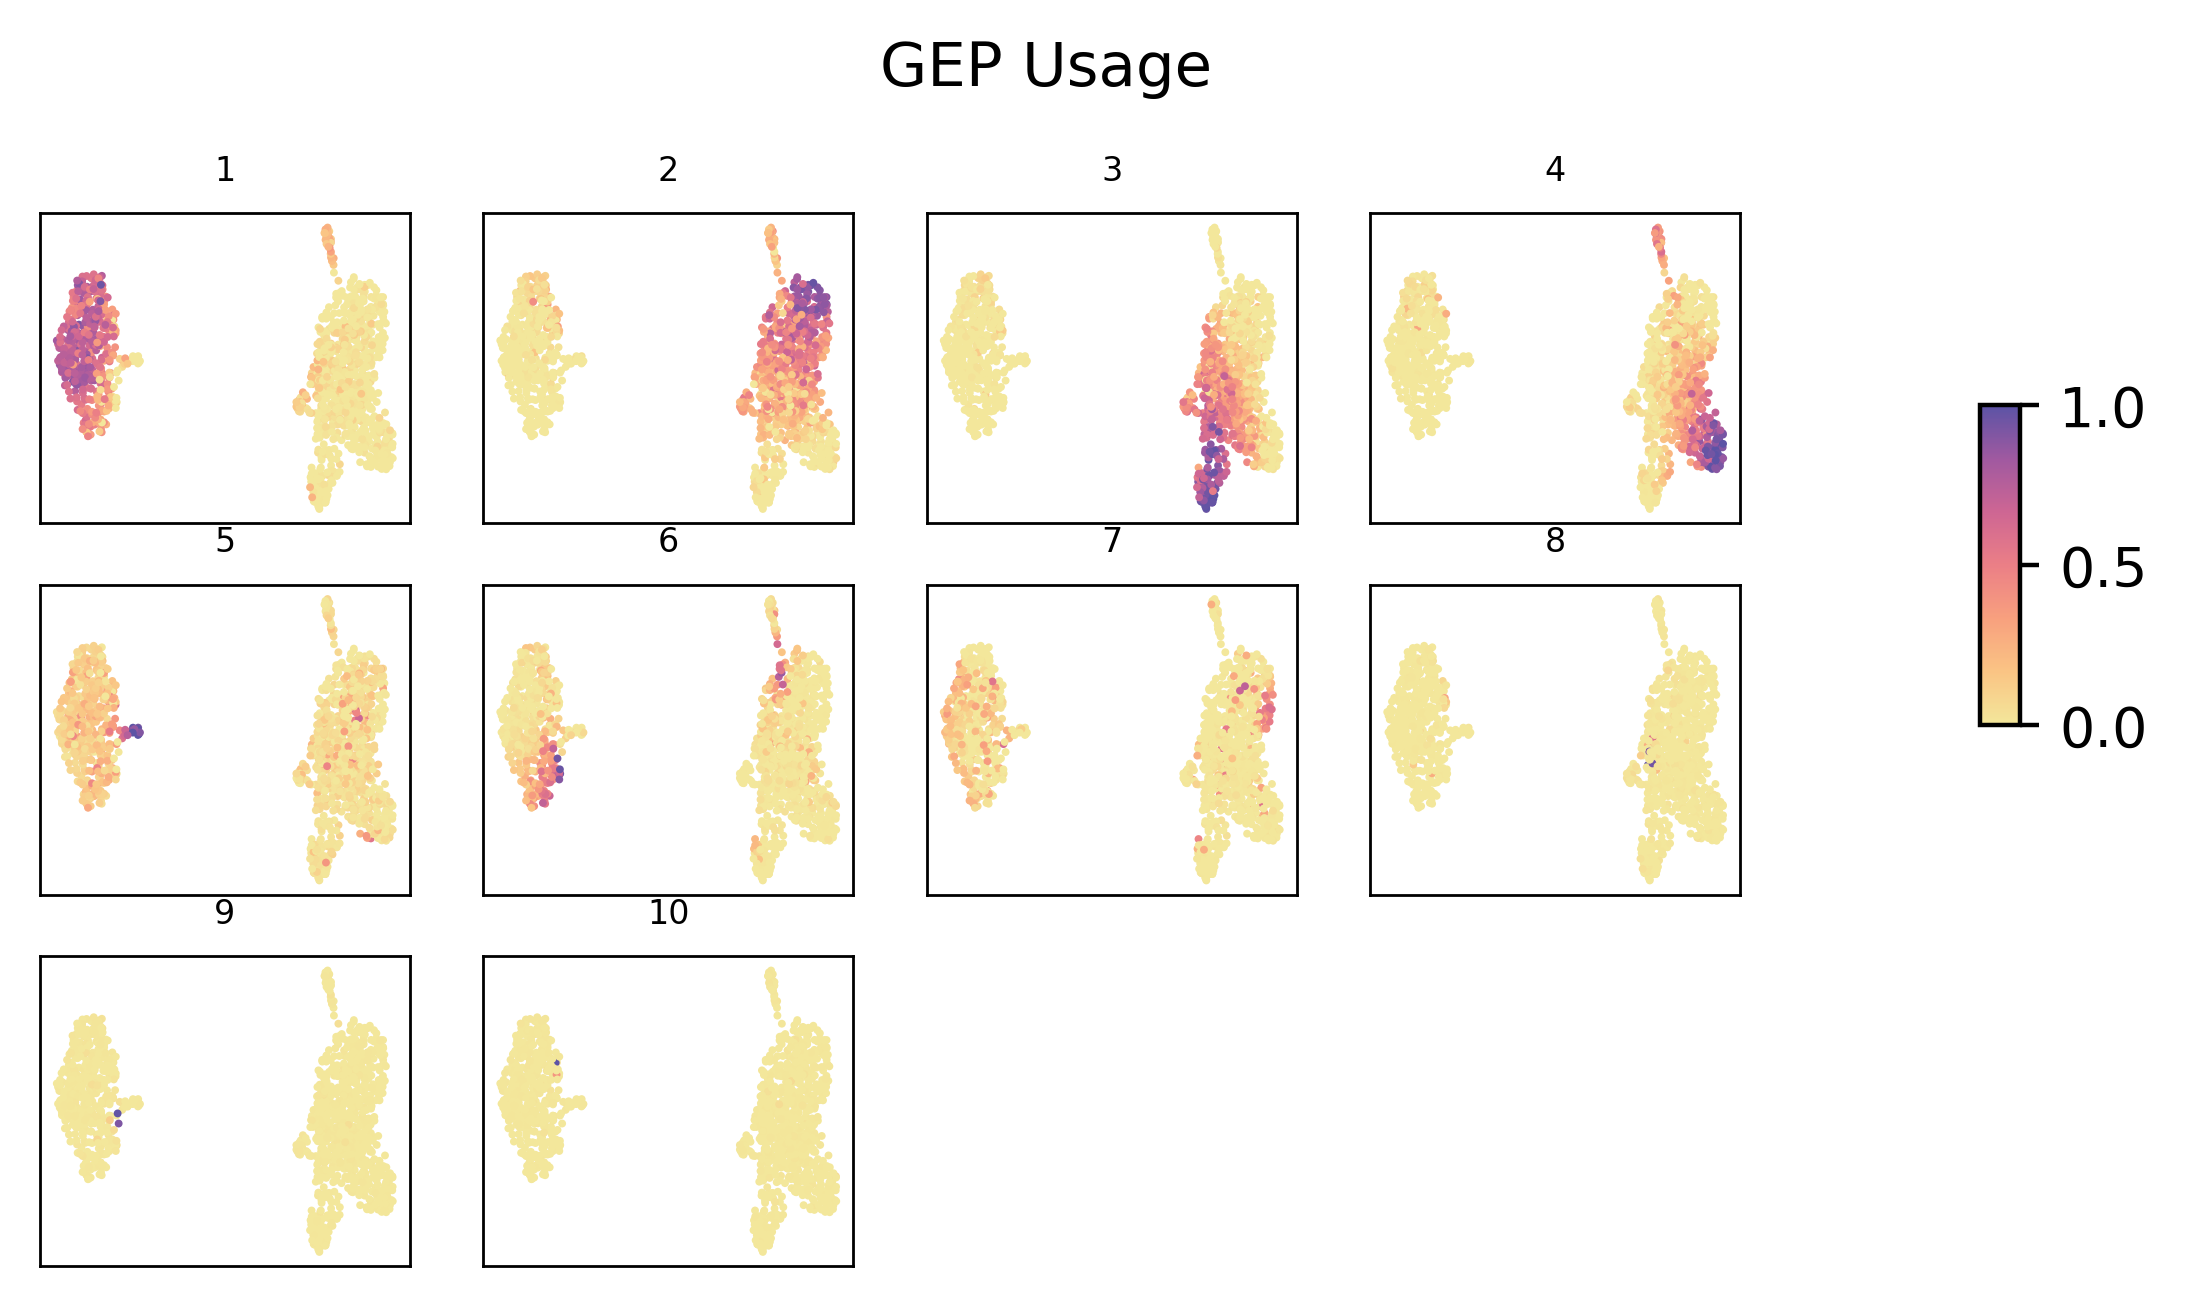

In [2]:
# start here to not rerun cnmf again
output_dir = "../outputs/cnmf_output_CCG1106_084_T1"
adata = sc.read_h5ad(f'{output_dir}/CCG1106_084_T1_with_programs.h5ad')
selected_K = 10
# Create dataframe with UMAP coords and program usage
tsne_and_usages = pd.DataFrame(
    adata.obsm['X_umap'],
    columns=['UMAP1', 'UMAP2'],
    index=adata.obs_names
)

# Add program usage
for i in range(1, selected_K + 1):
    tsne_and_usages[i] = adata.obs[f'Program_{i}'].values

cmap = palettable.cartocolors.sequential.Sunset_7.get_mpl_colormap()

# Create plot
fig, axes = plt.subplots(4, 4, figsize=(5, 4), dpi=400)
axes = axes.ravel()

for i in range(1, selected_K + 1):
    sc = axes[i-1].scatter(
        tsne_and_usages['UMAP1'], 
        tsne_and_usages['UMAP2'], 
        c=tsne_and_usages[i],
        cmap=cmap, 
        vmin=0, 
        vmax=1.0,
        s=2, 
        edgecolor='none', 
        rasterized=True
    )
    axes[i-1].set_title(f'{i}', fontsize=6)
    axes[i-1].set_xticks([])
    axes[i-1].set_yticks([])
    
    for spine in axes[i-1].spines.values():
        spine.set_linewidth(0.5)


plt.subplots_adjust(left=0.03, right=0.88, top=0.92, bottom=0.03,
                    hspace=0.20, wspace=0.20)


# Add colorbar
cbarax = fig.add_axes([1, 0.6, 0.02, 0.2])
plt.colorbar(sc, cax=cbarax)
_ = plt.figtext(0.45, 1, 'GEP Usage', fontsize=11)

axes[-1].remove()
axes[-2].remove()
axes[-3].remove()
axes[-4].remove()
axes[-5].remove()
axes[-6].remove()

plt.savefig(f"{output_dir}/UMAP_GEP_usage.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# print list of top 200 genes in program 1
# Load the spectra file
spectra = pd.read_csv("../outputs/cnmf_output_CCG1106_084_T1/CCG1106_084_T1_cNMF/CCG1106_084_T1_cNMF.gene_spectra_score.k_10.dt_0_1.txt", sep="\t", index_col=0)
program1_scores = spectra.iloc[0, :]
# Sort descending and take top 200
top200_program1 = program1_scores.sort_values(ascending=False).head(200)
top200_genes = top200_program1.index.tolist()

# print as list into a csv file
with open(f"{output_dir}/program1_top200_genes.txt", "w") as f:
    f.write(", ".join(top200_genes))

In [4]:
# Discard low usage programs
# For each program, count cells where it is the dominant program and has normalized usage >= 0.5
usage_threshold = 0.5
pct_threshold = 0.05
total_cells = adata.n_obs
min_cells = max(10, int(total_cells * pct_threshold))
print(f"Minimum cells required (5% of {total_cells}): {min_cells}")

program_dominance = {}

program_cols = [f'Program_{i}' for i in range(1, 11)]

for prog in program_cols:
    # Cells where this program is both dominant AND above usage threshold
    dominant_mask = (
        (adata.obs[program_cols].idxmax(axis=1) == prog) &
        (adata.obs[prog] >= usage_threshold)
    )
    n_dominant_cells = dominant_mask.sum()
    program_dominance[prog] = n_dominant_cells
    print(f"{prog}: {n_dominant_cells} cells with usage ≥ {usage_threshold}")

# Identify programs to discard
programs_to_discard = [
    prog for prog, n in program_dominance.items() 
    if n < min_cells
]
programs_to_retain = [
    prog for prog, n in program_dominance.items() 
    if n >= min_cells
]

print(f"\nRetained: {programs_to_retain}")
print(f"Discarded (< {min_cells} dominant cells): {programs_to_discard}")

Minimum cells required (5% of 1273): 63
Program_1: 296 cells with usage ≥ 0.5
Program_2: 205 cells with usage ≥ 0.5
Program_3: 159 cells with usage ≥ 0.5
Program_4: 108 cells with usage ≥ 0.5
Program_5: 26 cells with usage ≥ 0.5
Program_6: 33 cells with usage ≥ 0.5
Program_7: 16 cells with usage ≥ 0.5
Program_8: 6 cells with usage ≥ 0.5
Program_9: 2 cells with usage ≥ 0.5
Program_10: 1 cells with usage ≥ 0.5

Retained: ['Program_1', 'Program_2', 'Program_3', 'Program_4']
Discarded (< 63 dominant cells): ['Program_5', 'Program_6', 'Program_7', 'Program_8', 'Program_9', 'Program_10']


In [5]:
# supplementary table
retained = [int(prog.split('_')[-1]) for prog in programs_to_retain]
top_n = 50

top_genes = {}
for prog in retained:
    scores = spectra.iloc[prog - 1, :]
    top = scores.sort_values(ascending=False).head(top_n)
    top_genes[f"Program {prog}"] = top.index.tolist()

table = pd.DataFrame(top_genes)
table.index = range(1, top_n + 1)
table.index.name = "rank"

table.to_csv(f"{output_dir}/top50_genes_programs1-4.csv")
table.head(10)

,Program 1,Program 2,Program 3,Program 4
rank,,,,
1,ANGPT1,MIR100HG,ST6GALNAC3,SOX5
2,XKR4,MEG3,PRKCB,CDH6
3,NRXN1,CDH13,MMP13,CARMN
4,KCNMA1,MEG8,MMP9,LINC00989
5,PANX3,VEGFC,CEMIP,ADRA1A
6,PDGFDDN,MIR222HG,VAV3,PLCL1
7,EYA4,MIR493HG,TTC6,SLC6A1
8,ANO5,PDE4B,HS3ST3A1,RGS5
9,PID1,COL15A1,MEGF10,NRG3


dominant_program
Program 1    366
Program 2    325
Program 3    261
Program 4    178
Name: count, dtype: int64


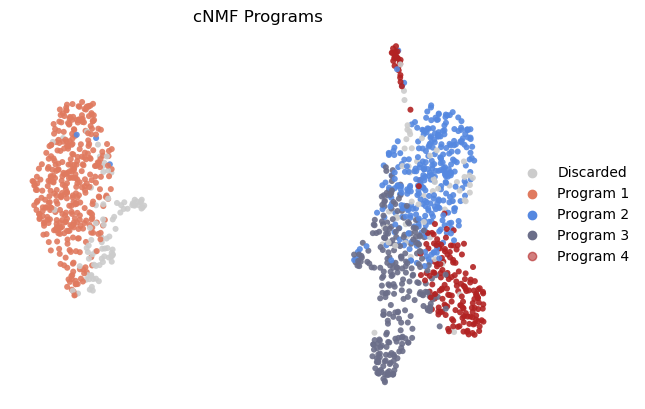

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
plt.close('all') 
# Get program columns
program_cols = [f'Program_{i}' for i in range(1, 11)]

# Assign each cell to its dominant program (highest usage score)
adata.obs['dominant_program'] = (
    adata.obs[program_cols]
    .idxmax(axis=1)  # returns e.g. 'Program_1'
    .str.replace('Program_', 'Program ')
)

# Define retained programs only (1-4)
retained = ['Program 1', 'Program 2', 'Program 3', 'Program 4']
print(adata.obs['dominant_program'].value_counts()[retained])

# Label discarded program cells as 'Discarded'
adata.obs['program_label'] = adata.obs['dominant_program'].apply(
    lambda x: x if x in retained else 'Discarded'
)

palette = {
    'Program 1': '#e07a5f',
    'Program 2': '#5588e0',  
    'Program 3': '#6b6e89ff',
    'Program 4': '#b2222295', 
    'Discarded': '#CCCCCC', 
}

sc.pl.umap(
    adata,
    size=75,
    color='program_label',
    palette=palette,
    alpha=0.9,
    title='cNMF Programs',
    frameon=False,
    show=False
)
plt.savefig(f"{output_dir}/UMAP_programs_paper.pdf", dpi=300, bbox_inches="tight",)
plt.show()
plt.close()

In [5]:
# load gene annotations
genes = pd.read_csv("../../../bulk_RNA/data/gene_coordinates.txt", sep="\t")
genes['Chromosome/scaffold name'] = genes['Chromosome/scaffold name'].replace({'X': '23', 'Y': '24'})
genes['Chromosome/scaffold name'] = pd.to_numeric(genes['Chromosome/scaffold name'])
genes = genes[(genes['Chromosome/scaffold name'] >= 1) & (genes['Chromosome/scaffold name'] <= 24)]

# Define regions of interest
regions = {
    "MYC": (8, 99000000, 137000000),
}

region_genes = {}
for name, (chrom, start, end) in regions.items():
    region_genes[name] = genes[
        (genes["Chromosome/scaffold name"] == chrom) &
        (genes["Gene start (bp)"] <= end) & 
        (genes["Gene end (bp)"] >= start)
    ]["Gene name"].dropna().tolist()

region_scores = {}
for region_name, gene_list in region_genes.items():
    genes_present = [g for g in gene_list if g in adata.var_names]
    print("region_name: ", region_name, " number of genes: ", len(genes_present))
    if genes_present:
        region_data = adata[:, genes_present].X
        region_scores[f'{region_name}_score'] = (
            region_data.toarray() if hasattr(region_data, 'toarray') else region_data
        ).mean(axis=1)

myc_threshold = 0.35

# Add to AnnData
for score_name, score_values in region_scores.items():
    adata.obs[score_name] = score_values

# Define MYC amplified cells
adata.obs['MYC_amplified'] = adata.obs['MYC_score'] > myc_threshold

print(f"\nMYC amplified cells (>{myc_threshold}): {adata.obs['MYC_amplified'].sum()}")

region_name:  MYC  number of genes:  207

MYC amplified cells (>0.35): 410


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_97828/3678602817.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[1].scatter(x[mask], y[mask],


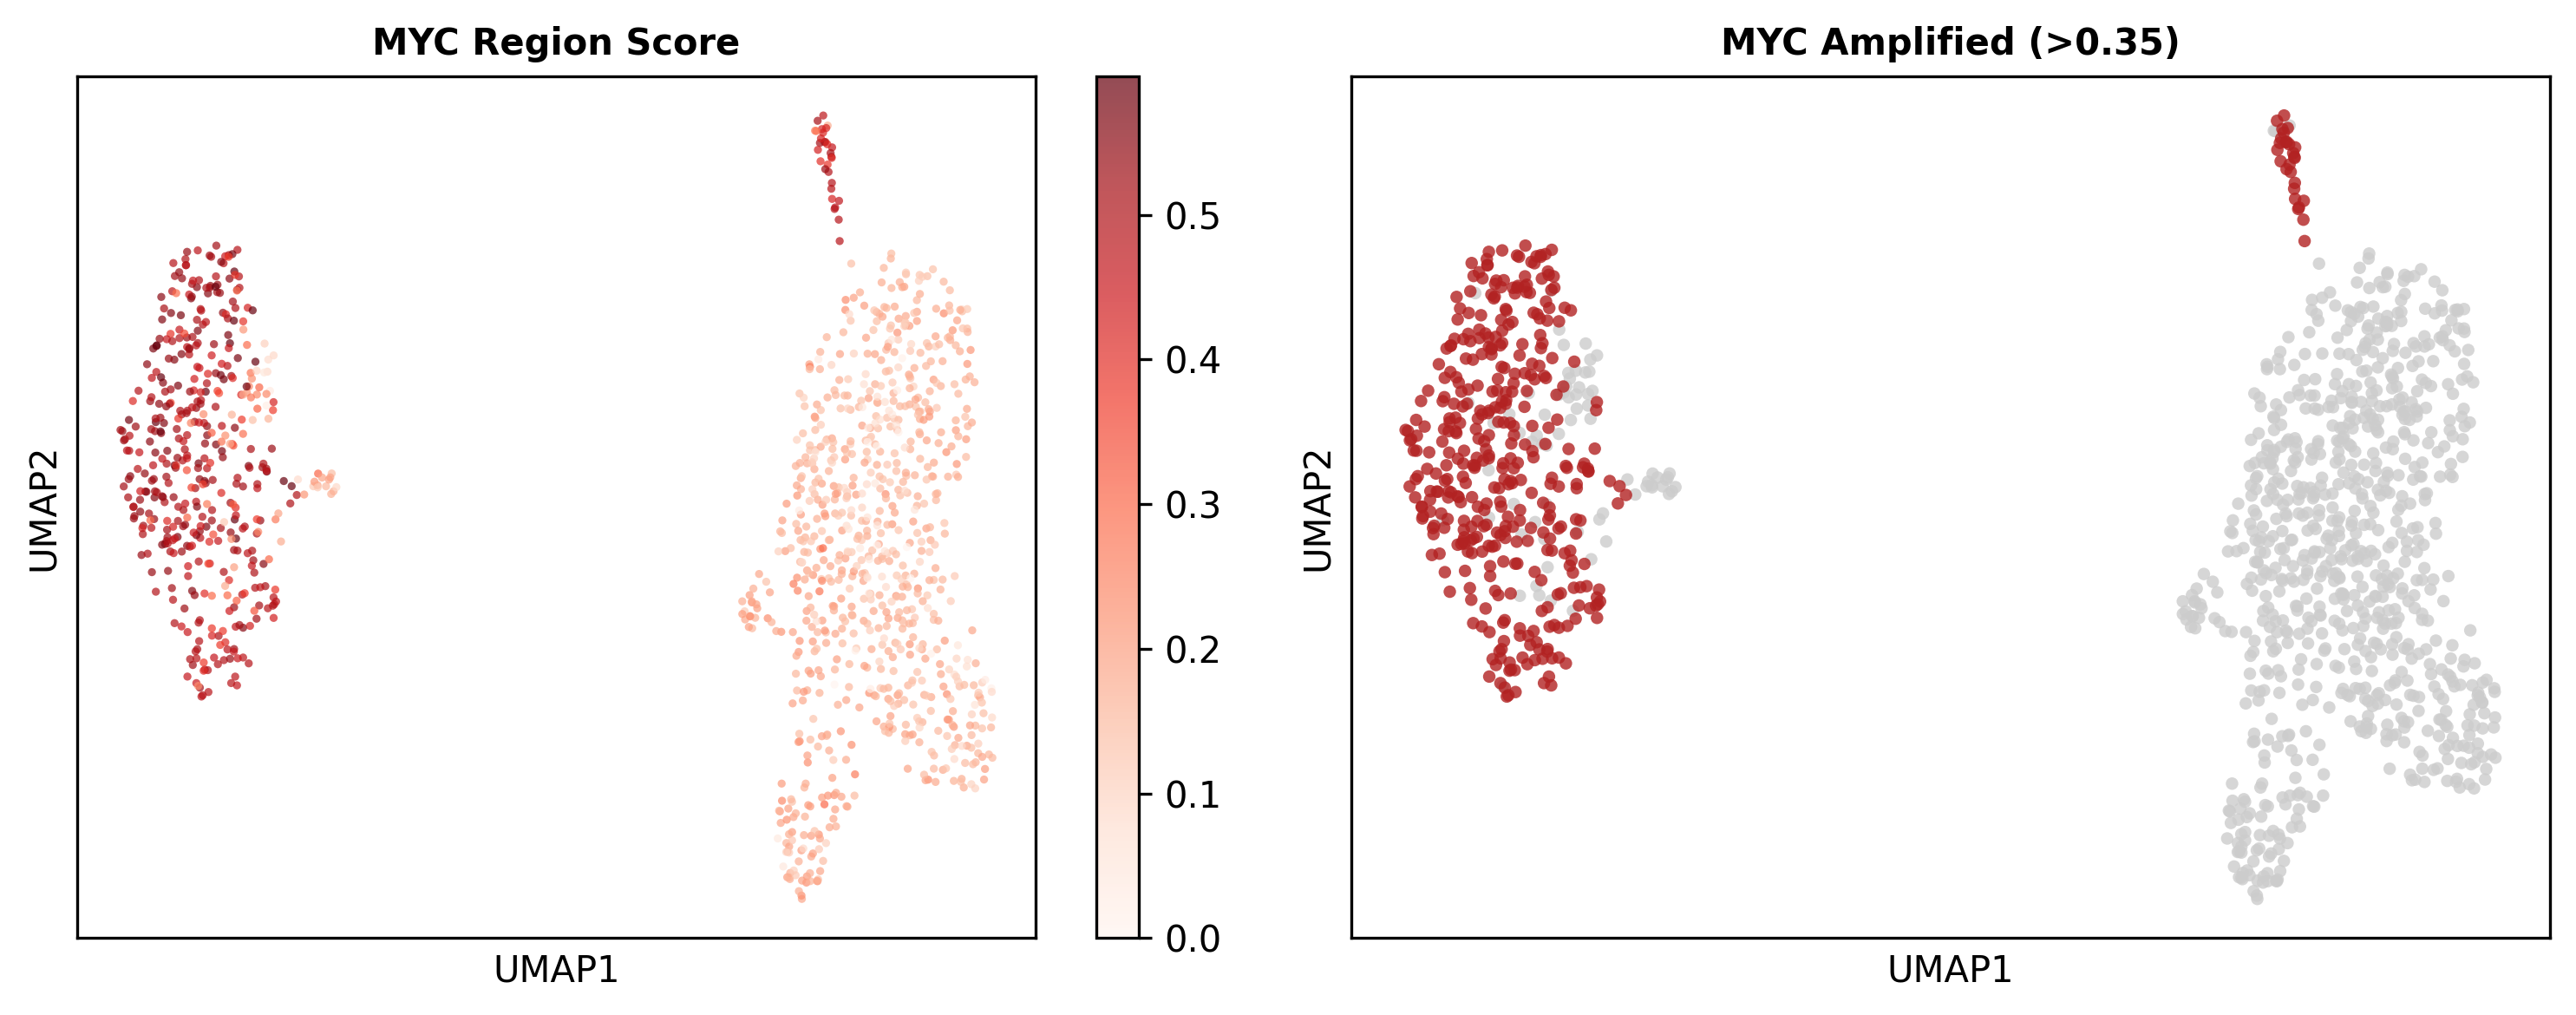

In [6]:
# Get UMAP coordinates
x = adata.obsm['X_umap'][:, 0]
y = adata.obsm['X_umap'][:, 1]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

# Plot 1: MYC score (continuous)
sc1 = axes[0].scatter(x, y, 
                      c=adata.obs['MYC_score'],
                      cmap='Reds',
                      s=5, alpha=0.7, edgecolor='none',
                      vmin=0, vmax=np.percentile(adata.obs['MYC_score'], 99))
axes[0].set_title('MYC Region Score', fontsize=10, weight='bold')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(sc1, ax=axes[0], label='')

# Plot 2: MYC amplified (binary)
colors = ['#CCCCCC', mcolors.to_rgba("#b22222", 0.58)]
labels = ['Non-amplified', 'MYC amplified']
for i, (ampl, color, label) in enumerate(zip([False, True], colors, labels)):
    mask = adata.obs['MYC_amplified'] == ampl
    axes[1].scatter(x[mask], y[mask],
                   c=color, s=12, alpha=0.8, edgecolor='none',
                   label=label)
axes[1].set_title(f'MYC Amplified (>{myc_threshold})', fontsize=10, weight='bold')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(f"{output_dir}/UMAP_MYC_score.pdf", dpi=300, bbox_inches='tight')
plt.show()

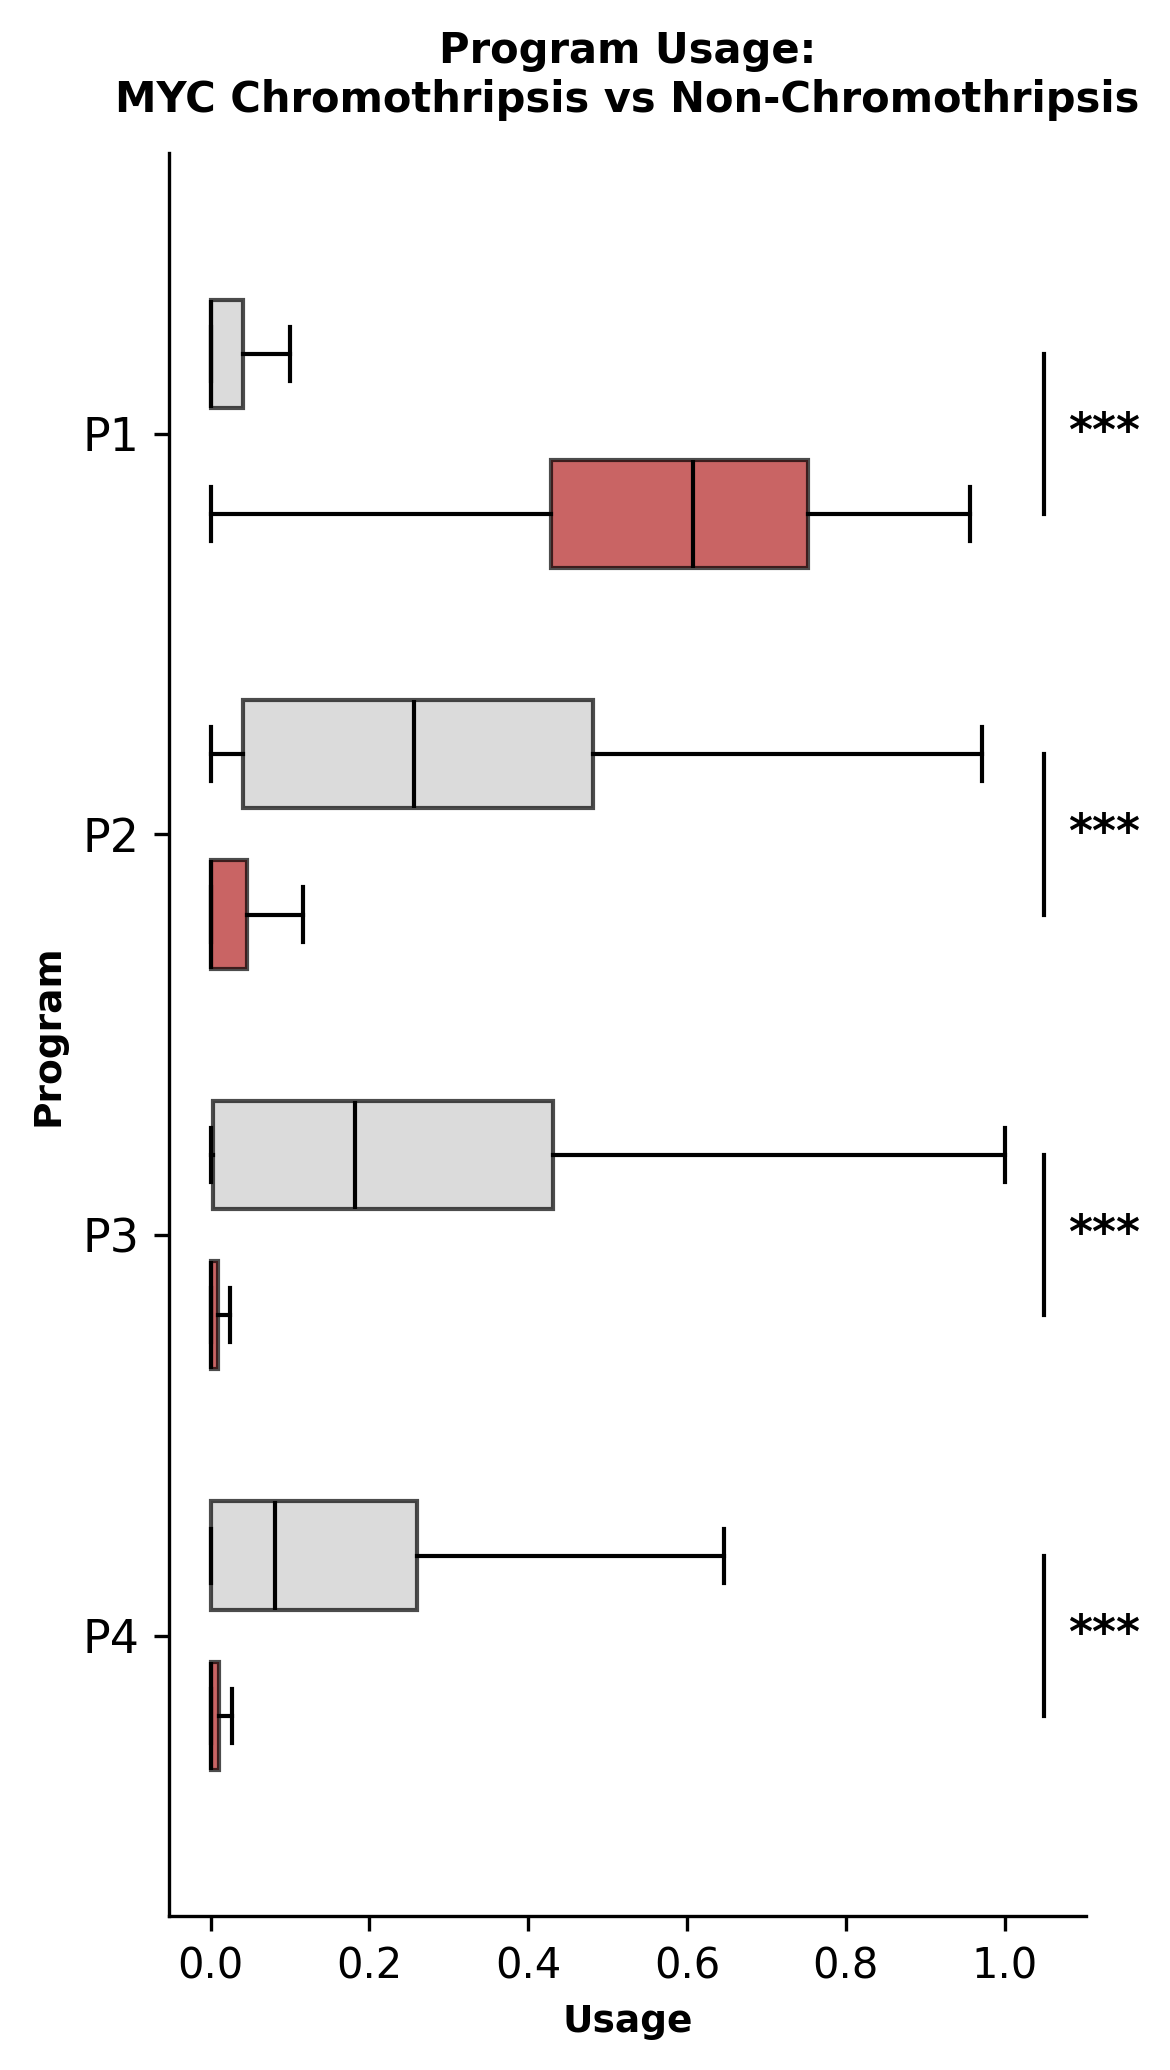


Statistical Summary:

Program 1:
  MYC-amp:  mean=0.5747, median=0.6071
  Non-amp:  mean=0.0489, median=0.0000
  Fold:     11.76x
  p-value:  2.53e-168

Program 2:
  MYC-amp:  mean=0.0361, median=0.0000
  Non-amp:  mean=0.3018, median=0.2559
  Fold:     0.12x
  p-value:  1.83e-79

Program 3:
  MYC-amp:  mean=0.0120, median=0.0000
  Non-amp:  mean=0.2639, median=0.1822
  Fold:     0.05x
  p-value:  2.69e-80

Program 4:
  MYC-amp:  mean=0.0335, median=0.0000
  Non-amp:  mean=0.1868, median=0.0806
  Fold:     0.18x
  p-value:  3.99e-49


In [ ]:
# Prepare data
program_cols = [f'Program_{i}' for i in range(1, 5)]

fig, ax = plt.subplots(figsize=(4, 7), dpi=300)  # tall, narrow

positions = []
data_to_plot = []
colors = []

myc_color = '#b22222'  # red
non_myc_color = '#CCCCCC'  # gray

for i in range(1, 5):
    prog_col = f'Program_{i}'
    non_amp = adata.obs[~adata.obs['MYC_amplified']][prog_col]
    myc_amp = adata.obs[adata.obs['MYC_amplified']][prog_col]
    
    positions.extend([i - 0.2, i + 0.2])
    data_to_plot.extend([non_amp, myc_amp])
    colors.extend([non_myc_color, myc_color])

bp = ax.boxplot(data_to_plot,
                positions=positions,
                widths=0.27,
                vert=False,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color='black', linewidth=1),
                boxprops=dict(linewidth=1),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Global x max (was y max)
global_x_max = 0
for prog_col in program_cols:
    myc_amp = adata.obs[adata.obs['MYC_amplified']][prog_col]
    non_amp = adata.obs[~adata.obs['MYC_amplified']][prog_col]
    global_x_max = max(global_x_max, myc_amp.max(), non_amp.max())

# Significance bars now go on the x-axis side
for i, prog_col in enumerate(program_cols, 1):
    myc_amp = adata.obs[adata.obs['MYC_amplified']][prog_col]
    non_amp = adata.obs[~adata.obs['MYC_amplified']][prog_col]
    stat, pval = stats.mannwhitneyu(myc_amp, non_amp, alternative='two-sided')
    
    if pval < 0.001: sig_text = '***'
    elif pval < 0.01: sig_text = '**'
    elif pval < 0.05: sig_text = '*'
    else: sig_text = 'ns'
    
    # Vertical bracket line, text to the right
    ax.plot([global_x_max * 1.05, global_x_max * 1.05], [i - 0.2, i + 0.2], 'k-', linewidth=1)
    ax.text(global_x_max * 1.08, i, sig_text, ha='left', va='center',
            fontsize=11, weight='bold')

ax.set_yticks(range(1, 5))
ax.set_yticklabels([f'P{i}' for i in range(1, 5)], fontsize=11)
ax.set_ylabel('Program', fontsize=9, weight='bold')
ax.set_xlabel('Usage', fontsize=9, weight='bold')
ax.set_title('Program Usage:\nMYC Chromothripsis vs Non-Chromothripsis',
             fontsize=10, weight='bold', pad=10)
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [Patch(facecolor=non_myc_color, alpha=0.7, label='Non-amp'),
                   Patch(facecolor=myc_color, alpha=0.7, label='MYC-amp')]
#ax.legend(handles=legend_elements, fontsize=9, frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_program_usage_by_MYC.pdf", dpi=300, bbox_inches='tight')
plt.show()

print("\nStatistical Summary:")
for i, prog_col in enumerate(program_cols, 1):
    myc_amp = adata.obs[adata.obs['MYC_amplified']][prog_col]
    non_amp = adata.obs[~adata.obs['MYC_amplified']][prog_col]
    
    stat, pval = stats.mannwhitneyu(myc_amp, non_amp, alternative='two-sided')
    
    print(f"\nProgram {i}:")
    print(f"  MYC-amp:  mean={myc_amp.mean():.4f}, median={myc_amp.median():.4f}")
    print(f"  Non-amp:  mean={non_amp.mean():.4f}, median={non_amp.median():.4f}")
    print(f"  Fold:     {myc_amp.mean() / non_amp.mean():.2f}x")
    print(f"  p-value:  {pval:.2e}")

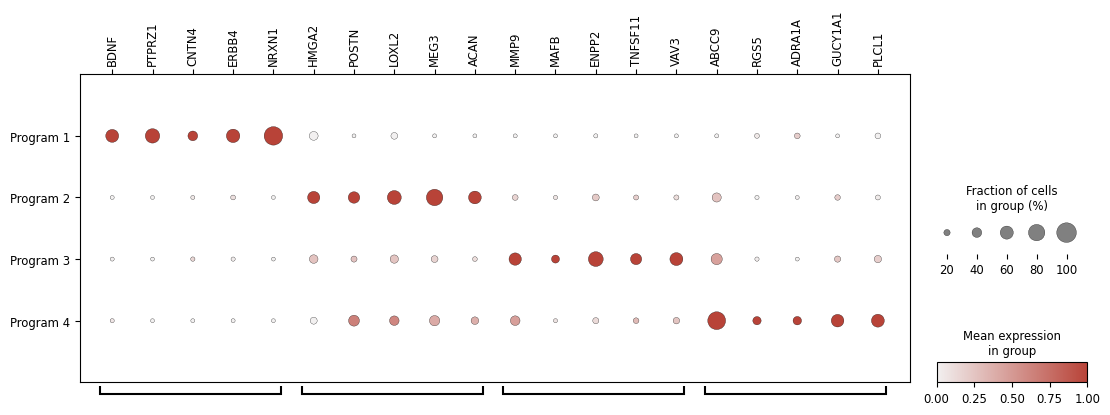

In [19]:
marker_genes = {
    'Program 1': [
        'BDNF', 'PTPRZ1', 'CNTN4', 
        'ERBB4', 'NRXN1'
    ],
    'Program 2': [
        'HMGA2', 'POSTN', 'LOXL2',
        'MEG3', 'ACAN'
    ],
    'Program 3': [
        'MMP9', 'MAFB', 'ENPP2',
        'TNFSF11', 'VAV3'
    ],
    'Program 4': [
        'ABCC9', 'RGS5', 'ADRA1A',
        'GUCY1A1', 'PLCL1'
    ]
}

# Subset to retained programs only
retained_programs = ['Program 1', 'Program 2', 'Program 3', 'Program 4']
adata_retained = adata[adata.obs['program_label'].isin(retained_programs)].copy()

dp = sc.pl.dotplot(
    adata_retained,
    var_names=marker_genes,
    groupby='program_label',
    categories_order=retained_programs,
    standard_scale='var',
    color_map=sns.light_palette((15, 70, 45), input="husl", as_cmap=True),
    dot_max=1.0,
    figsize=(13, 4),
    show=False,
    return_fig=True,
)

dp = dp.style(size_exponent=1.7, smallest_dot = 8)
dp.make_figure()

ax_dict = dp.get_axes()
main_ax = ax_dict['mainplot_ax']
main_ax.margins(y=0.01)
main_ax.xaxis.tick_top()
main_ax.xaxis.set_label_position('top')
plt.setp(main_ax.get_xticklabels(), rotation=90, ha='center')

# Brackets at bottom, no labels
if 'gene_group_ax' in ax_dict:
    gene_ax = ax_dict['gene_group_ax']
    main_pos = main_ax.get_position()
    gene_pos = gene_ax.get_position()
    gene_ax.set_position([
        gene_pos.x0,
        main_pos.y0 - gene_pos.height - 0.01,
        gene_pos.width,
        gene_pos.height
    ])
    gene_ax.invert_yaxis()
    for text in gene_ax.texts:
        text.set_visible(False)
    gene_ax.set_yticklabels([])

# 5. Fix the stretched Legend
# Adjust the position: [left, bottom, width, height]
if 'color_legend_ax' in ax_dict:
    cbar_ax = ax_dict['color_legend_ax']
    pos = cbar_ax.get_position()
    # This keeps the legend in place but makes it shorter (0.3 of the plot height)
    cbar_ax.set_position([pos.x0, pos.y0, pos.width, 0.05])

plt.savefig(f"{output_dir}/program_genes_dotplot.pdf", dpi=300, bbox_inches="tight",)
plt.show()
plt.close()